# 07 — Machine Learning Claim Audit & Feasibility Assessment
**Project:** AI-Based Urban Change & Environmental Risk Intelligence for Chittoor District, AP  
**Stage:** Model Selection, ML Feasibility & Scientific Claim Governance  

### Objectives:
1. Formally audit the project title: *"AI-Based Urban Change & Environmental Risk Intelligence"*.
2. Expose the prediction feasibility assessment: evaluate why deep learning (LSTM, CNN) and complex ML (Random Forest, GBDT) are scientifically unviable on $N=10$ annual points.
3. Quantify overfitting risk, degrees of freedom, and sample size constraints.
4. Establish the legitimate roles of AI in the project (Dynamic World Deep Learning FCN) versus transparent statistical forecasting.

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(project_root))

feasibility_path = project_root / "outputs" / "tables" / "prediction_feasibility_matrix.csv"
df_feas = pd.read_csv(feasibility_path)
df_feas[["target", "temporal_frequency", "observation_count", "ML_possible", "deep_learning_possible", "recommended_method", "confidence_level"]]

,target,temporal_frequency,observation_count,ML_possible,deep_learning_possible,recommended_method,confidence_level
0,Total Built-Up Area (built_up_km2),Annual,10,No (Sample size N=10 causes severe overfitting in Random Forest / GBDT),No (Insufficient training sample for LSTM/CNN/Transformer),OLS Linear Trend Extrapolation with 95% Prediction Intervals,Category A — FORECASTING RECOMMENDED
1,Strong Built-Up Core (strong_built_up_km2),Annual,10,No (Sample size N=10 causes severe overfitting),No (Insufficient training sample),OLS Linear Trend Extrapolation with 95% Prediction Intervals,Category A — FORECASTING RECOMMENDED
2,Annual NDVI (NDVI),Annual,10,No (Stochastic climate noise cannot be learned from N=10),No (Completely unviable),Historical Baseline / Observational Monitoring Only,Category B — FORECASTING POSSIBLE BUT HIGH UNCERTAINTY
3,Annual Daytime LST (LST_C),Annual,10,No (Overfitting),No (Completely unviable),None — Retain as Observational Environmental Metric,Category C — FORECASTING NOT SCIENTIFICALLY DEFENSIBLE
4,Annual Rainfall (rainfall_mm),Annual,10,No (Pure noise fitting),No (Completely unviable),None — Use Climatological Normals,Category C — FORECASTING NOT SCIENTIFICALLY DEFENSIBLE
5,Decadal Spatial Environmental Stress (1 km Grid),Decadal Transition,1,No (Requires historical multi-epoch spatial ground truth),No,None — Maintain as Observational Spatial Risk Baseline,Category C — NOT CURRENTLY FEASIBLE
6,Pixel-Level Satellite Image Prediction (Sentinel-2 10m),Decadal Snapshots,2,No,No (CNN/U-Net requires thousands of temporal sequences),None — Observational & Change Detection Asset Only,Category C — NOT SCIENTIFICALLY DEFENSIBLE


## 1. Degrees of Freedom & Overfitting Demonstration
Demonstrate why fitting a multi-parameter model on $N = 10$ annual observations leads to memorization rather than generalization.

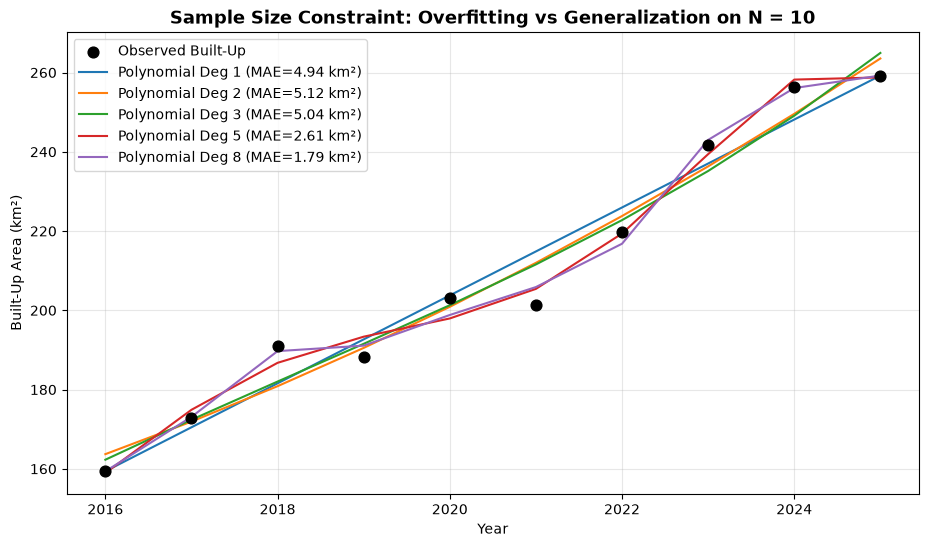

In [2]:
df_master = pd.read_csv(project_root / "data" / "processed" / "Chittoor_Master_Research_Dataset_2016_2025.csv")
y = df_master["built_up_km2"].values
x = np.arange(len(y))

# Fit polynomials from degree 1 (linear) to degree 8
poly_results = {}
for deg in [1, 2, 3, 5, 8]:
    p = np.polyfit(x, y, deg=deg)
    y_pred = np.polyval(p, x)
    mae = np.mean(np.abs(y - y_pred))
    poly_results[deg] = (p, y_pred, mae)

plt.figure(figsize=(11, 6))
plt.scatter(df_master["year"], y, color="black", s=60, zorder=5, label="Observed Built-Up")
for deg, (p, y_pred, mae) in poly_results.items():
    plt.plot(df_master["year"], y_pred, label=f"Polynomial Deg {deg} (MAE={mae:.2f} km²)")

plt.title("Sample Size Constraint: Overfitting vs Generalization on N = 10", fontsize=13, fontweight="bold")
plt.xlabel("Year")
plt.ylabel("Built-Up Area (km²)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## 2. Formal AI / Machine Learning Audit
Document where genuine AI/ML exists in the project continuum:
1. **Dynamic World (Google / WRI):** Deep learning Fully Convolutional Network (FCN) trained on Sentinel-2 optical scenes produces authoritative 10 m pixel-level land cover probabilities.
2. **Spatial Analytics & Autocorrelation:** Global Moran's I geostatistical inference.
3. **Forecasting:** Walk-forward validated statistical extrapolation with analytical prediction intervals.
4. **Feasibility Decision:** Senior Data Science judgment rejects deep learning (LSTM/CNN) on N=10 to preserve scientific credibility.